In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
iris = pd.read_csv("Iris.csv")
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
X = iris.drop('Species', axis=1)
Y = iris['Species']

print(X)
print(Y)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      1            5.1           3.5            1.4           0.2
1      2            4.9           3.0            1.4           0.2
2      3            4.7           3.2            1.3           0.2
3      4            4.6           3.1            1.5           0.2
4      5            5.0           3.6            1.4           0.2
..   ...            ...           ...            ...           ...
145  146            6.7           3.0            5.2           2.3
146  147            6.3           2.5            5.0           1.9
147  148            6.5           3.0            5.2           2.0
148  149            6.2           3.4            5.4           2.3
149  150            5.9           3.0            5.1           1.8

[150 rows x 5 columns]
0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virgin

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
def evaluate_model(model, X, Y):

    print("\n" + "#"*60)
    print(" MODEL: " + model.__class__.__name__)
    print("#"*60)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    acc_scores = []
    train_acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_index, test_index) in enumerate(skf.split(X, Y), 1):

        print("\n")
        print("Fold:", fold)

        X_train = X[train_index]
        X_test = X[test_index]

        Y_train = Y.iloc[train_index]
        Y_test = Y.iloc[test_index]

        # Train
        model.fit(X_train, Y_train)

        # Predict
        Y_pred = model.predict(X_test)
        Y_train_pred = model.predict(X_train)

        # Metrics
        acc = metrics.accuracy_score(Y_test, Y_pred)
        train_acc = metrics.accuracy_score(Y_train, Y_train_pred)
        precision = metrics.precision_score(Y_test, Y_pred, average='macro')
        recall = metrics.recall_score(Y_test, Y_pred, average='macro')
        f1 = metrics.f1_score(Y_test, Y_pred, average='macro')

        print("Train Accuracy :", round(train_acc, 4))
        print("Test Accuracy  :", round(acc, 4))
        print("Precision      :", round(precision, 4))
        print("Recall         :", round(recall, 4))
        print("F1 Score       :", round(f1, 4))

        acc_scores.append(acc)
        train_acc_scores.append(train_acc)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        # Confusion Matrix
        cm = metrics.confusion_matrix(Y_test, Y_pred)

        print("\nConfusion Matrix:")
        plot_confusion_matrix(conf_mat=cm, class_names=model.classes_)
        plt.title(f"Confusion Matrix - Fold {fold}")
        plt.show()

        # Classification Report
        print("\nClassification Report:")
        print(metrics.classification_report(Y_test, Y_pred))

    # Final Results
    print("\nFINAL")
    print("Average Train Accuracy :", round(np.mean(train_acc_scores), 4))
    print("Average Test Accuracy  :", round(np.mean(acc_scores), 4))
    print("Average Precision      :", round(np.mean(precision_scores), 4))
    print("Average Recall         :", round(np.mean(recall_scores), 4))
    print("Average F1 Score       :", round(np.mean(f1_scores), 4))


KNN

############################################################
 MODEL: KNeighborsClassifier
############################################################


Fold: 1
Train Accuracy : 0.9917
Test Accuracy  : 1.0
Precision      : 1.0
Recall         : 1.0
F1 Score       : 1.0

Confusion Matrix:


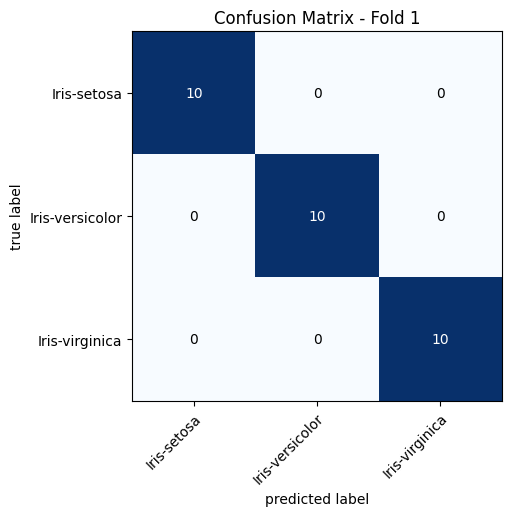


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Fold: 2
Train Accuracy : 1.0
Test Accuracy  : 0.9667
Precision      : 0.9697
Recall         : 0.9667
F1 Score       : 0.9666

Confusion Matrix:


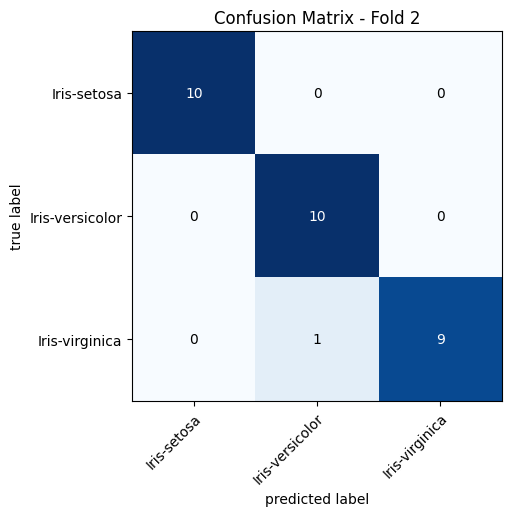


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



Fold: 3
Train Accuracy : 0.9917
Test Accuracy  : 1.0
Precision      : 1.0
Recall         : 1.0
F1 Score       : 1.0

Confusion Matrix:


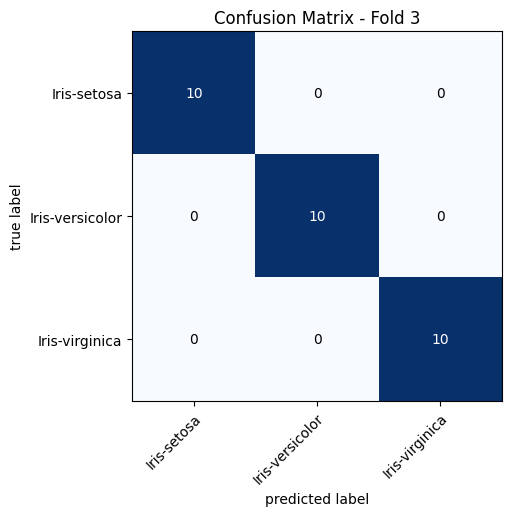


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Fold: 4
Train Accuracy : 0.9917
Test Accuracy  : 1.0
Precision      : 1.0
Recall         : 1.0
F1 Score       : 1.0

Confusion Matrix:


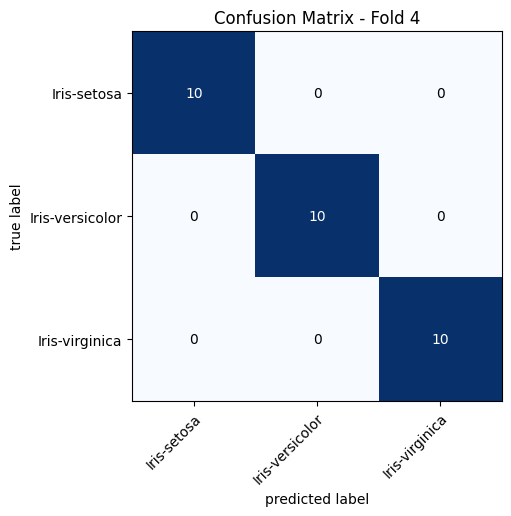


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Fold: 5
Train Accuracy : 0.9917
Test Accuracy  : 0.9667
Precision      : 0.9697
Recall         : 0.9667
F1 Score       : 0.9666

Confusion Matrix:


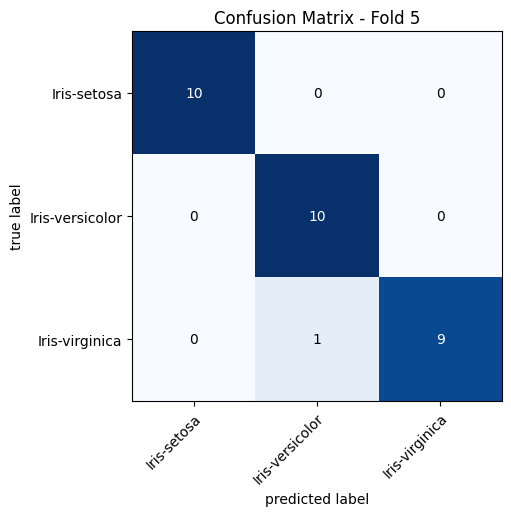


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


FINAL
Average Train Accuracy : 0.9933
Average Test Accuracy  : 0.9867
Average Precision      : 0.9879
Average Recall         : 0.9867
Average F1 Score       : 0.9866


In [6]:
print("\nKNN")
model_knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(model_knn, X_scaled, Y)